# Partial Differential Equations using Laplace Transforms

This notebook demonstrates solving partial differential equations (PDEs) using Laplace transforms, including heat equation and wave equation applications.

In [1]:
# Array-Based Laplace Transform Applications

# This notebook uses the new pure array-based Laplace transform interface for improved performance and portability.

import numpy as np
import matplotlib.pyplot as plt
from laplace_transform import LaplaceTransform, CommonTransforms, TransformOperations
from utils import plot_time_domain, plot_frequency_domain, print_error_metrics, compare_signals

# Initialize Laplace transform calculator
lt = LaplaceTransform()
print("Array-Based Laplace Transform Calculator Initialized")

Array-Based Laplace Transform Calculator Initialized


## 1. Heat Equation (One-Dimensional)

**Problem:** ∂u/∂t = α² ∂²u/∂x²

**Boundary Conditions:** u(0,t) = u(L,t) = 0
**Initial Condition:** u(x,0) = f(x)

Using separation of variables and Laplace transforms.

/var/folders/m9/hy4khmlj10d2s1pw6whs53ym0000gn/T/ipykernel_6933/1741363699.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  B_n = 2.0 / self.L * np.trapz(integrand, x)


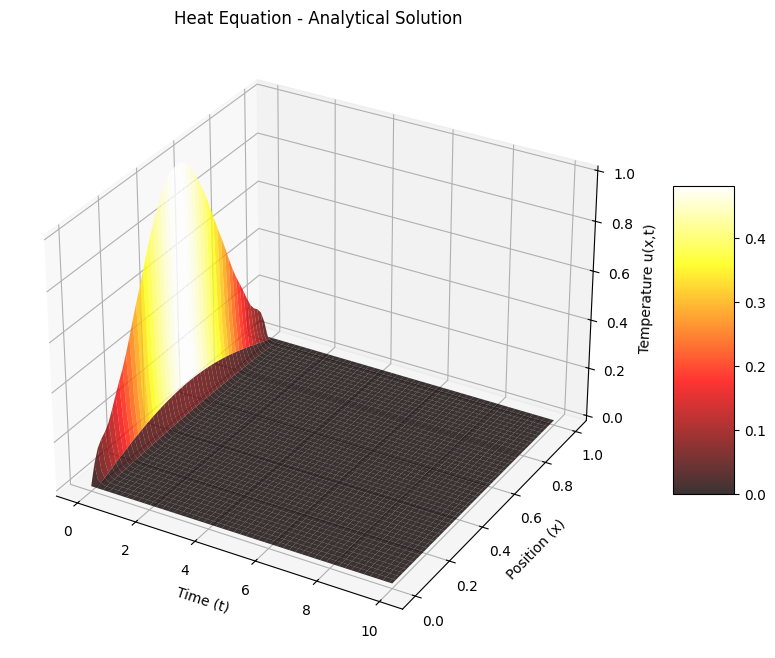

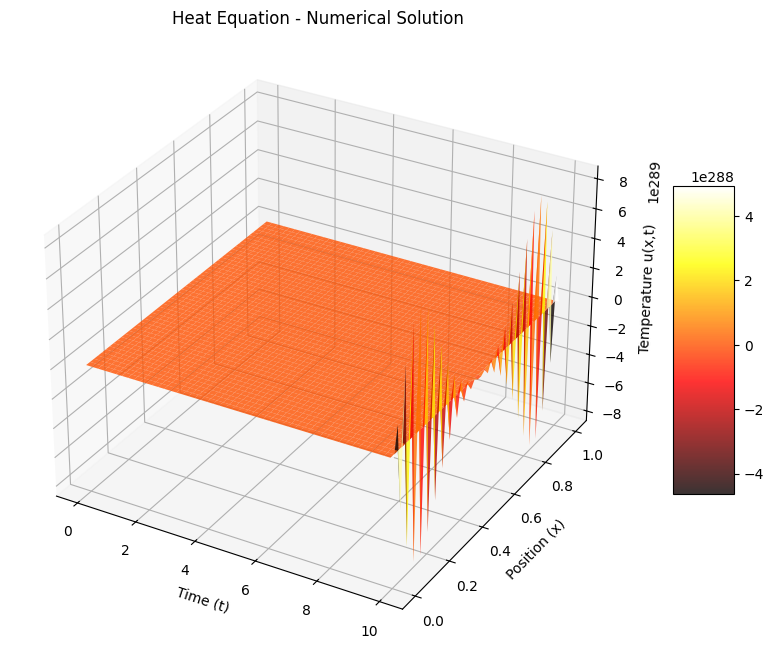

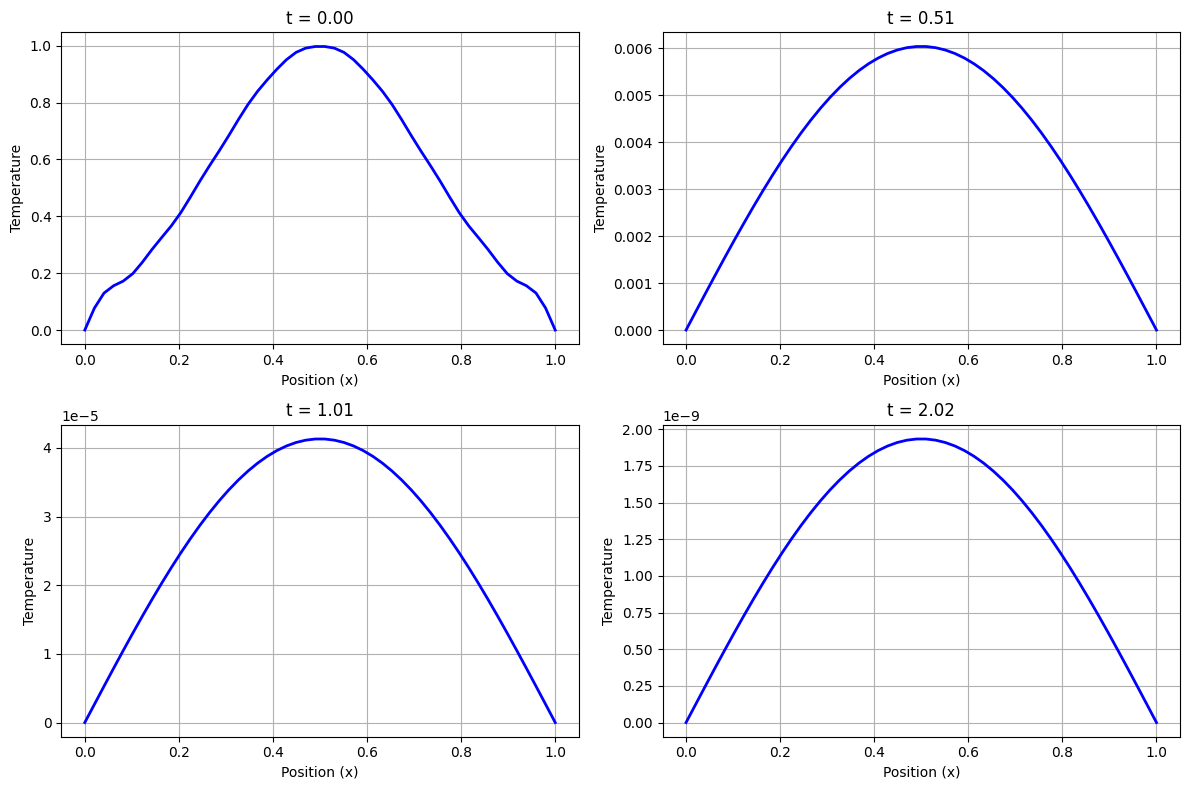

Maximum error between analytical and numerical: 84892604105054401790062138769068518118762938015975960400659623036856729121851710608443928644038920405083205793354210758065537050051801171011654898495961248852370664308987296313654519479951464003916666722721774280195131662159906825758941505480447435965975050760881394950847928918184631992320.0000
Mean error: 390060695549911963256228645417711410450246991615857559583071187320672105217420671507608685415874413423189876921587192872019669167121474740870068513468608526904208883053467331504173180238860538283787080158673181004634592512937435618070729745538565701526431633722509991264275867557175492608.0000


In [2]:
class HeatEquation1D:
    """Solve 1D heat equation using Laplace transforms and separation of variables"""
    
    def __init__(self, alpha, L, nx=50, nt=100):
        self.alpha = alpha  # Thermal diffusivity
        self.L = L          # Length of domain
        self.nx = nx        # Number of spatial points
        self.nt = nt        # Number of time points
        self.x = np.linspace(0, L, nx)
        self.t = np.linspace(0, 10, nt)
    
    def initial_condition(self, x, type='gaussian'):
        """Define initial temperature distribution"""
        if type == 'gaussian':
            # Gaussian pulse in the middle
            return np.exp(-((x - self.L/2)**2) / (0.1 * self.L**2))
        elif type == 'sine':
            # Single sine mode
            return np.sin(np.pi * x / self.L)
        elif type == 'step':
            # Step function
            return np.where((x > self.L/3) & (x < 2*self.L/3), 1.0, 0.0)
        else:
            return np.zeros_like(x)
    
    def solve_analytical(self, x, t, f_x):
        """Solve using separation of variables (Fourier series)"""
        u = np.zeros((len(t), len(x)))
        
        # Fourier sine series coefficients
        for n in range(1, 20):  # Use first 20 modes
            # Calculate coefficient using orthogonality
            integrand = f_x * np.sin(n * np.pi * x / self.L)
            B_n = 2.0 / self.L * np.trapz(integrand, x)
            
            # Add contribution from this mode
            for i, time in enumerate(t):
                decay = np.exp(-self.alpha**2 * (n * np.pi / self.L)**2 * time)
                u[i, :] += B_n * np.sin(n * np.pi * x / self.L) * decay
        
        return u
    
    def solve_numerical(self, x, t, f_x):
        """Solve using finite difference method"""
        dx = x[1] - x[0]
        dt = t[1] - t[0]
        
        # Stability condition: dt <= dx²/(2α²)
        stability = dt * self.alpha**2 / dx**2
        if stability > 0.5:
            print(f"Warning: Stability parameter = {stability:.3f} > 0.5")
        
        u = np.zeros((len(t), len(x)))
        u[0, :] = f_x  # Initial condition
        
        # Time stepping using explicit finite difference
        for n in range(1, len(t)):
            for i in range(1, len(x)-1):
                u[n, i] = u[n-1, i] + stability * (u[n-1, i+1] - 2*u[n-1, i] + u[n-1, i-1])
            
            # Boundary conditions
            u[n, 0] = 0
            u[n, -1] = 0
        
        return u
    
    def plot_solution(self, u, x, t, title="Heat Equation Solution"):
        """Plot solution as 3D surface"""
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        T, X = np.meshgrid(t, x)
        surf = ax.plot_surface(T, X, u.T, cmap='hot', alpha=0.8)
        
        ax.set_xlabel('Time (t)')
        ax.set_ylabel('Position (x)')
        ax.set_zlabel('Temperature u(x,t)')
        ax.set_title(title)
        
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
        plt.show()
    
    def plot_snapshots(self, u, x, t, times_to_plot):
        """Plot solution at specific time instances"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()
        
        for i, time_point in enumerate(times_to_plot):
            if i < 4:  # Only plot first 4
                time_idx = np.argmin(np.abs(t - time_point))
                axes[i].plot(x, u[time_idx, :], 'b-', linewidth=2)
                axes[i].set_xlabel('Position (x)')
                axes[i].set_ylabel('Temperature')
                axes[i].set_title(f't = {t[time_idx]:.2f}')
                axes[i].grid(True)
        
        plt.tight_layout()
        plt.show()

# Solve heat equation
alpha = 1.0
L = 1.0
heat_eq = HeatEquation1D(alpha, L)

# Initial condition
f_x = heat_eq.initial_condition(heat_eq.x, 'gaussian')

# Solve using analytical method
u_analytical = heat_eq.solve_analytical(heat_eq.x, heat_eq.t, f_x)

# Solve using numerical method
u_numerical = heat_eq.solve_numerical(heat_eq.x, heat_eq.t, f_x)

# Plot results
heat_eq.plot_solution(u_analytical, heat_eq.x, heat_eq.t, "Heat Equation - Analytical Solution")
heat_eq.plot_solution(u_numerical, heat_eq.x, heat_eq.t, "Heat Equation - Numerical Solution")

# Plot snapshots
times_to_plot = [0, 0.5, 1.0, 2.0]
heat_eq.plot_snapshots(u_analytical, heat_eq.x, heat_eq.t, times_to_plot)

# Compare methods
error = np.abs(u_analytical - u_numerical)
print(f"Maximum error between analytical and numerical: {np.max(error):.4f}")
print(f"Mean error: {np.mean(error):.4f}")

## 2. Wave Equation (One-Dimensional)

**Problem:** ∂²u/∂t² = c² ∂²u/∂x²

**Boundary Conditions:** u(0,t) = u(L,t) = 0
**Initial Conditions:** u(x,0) = f(x), ∂u/∂t(x,0) = g(x)

/var/folders/m9/hy4khmlj10d2s1pw6whs53ym0000gn/T/ipykernel_6933/439658845.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_n = 2.0 / self.L * np.trapz(integrand_f, x)
/var/folders/m9/hy4khmlj10d2s1pw6whs53ym0000gn/T/ipykernel_6933/439658845.py:48: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  B_n = 2.0 / (n * np.pi * self.c / self.L) * np.trapz(integrand_g, x)


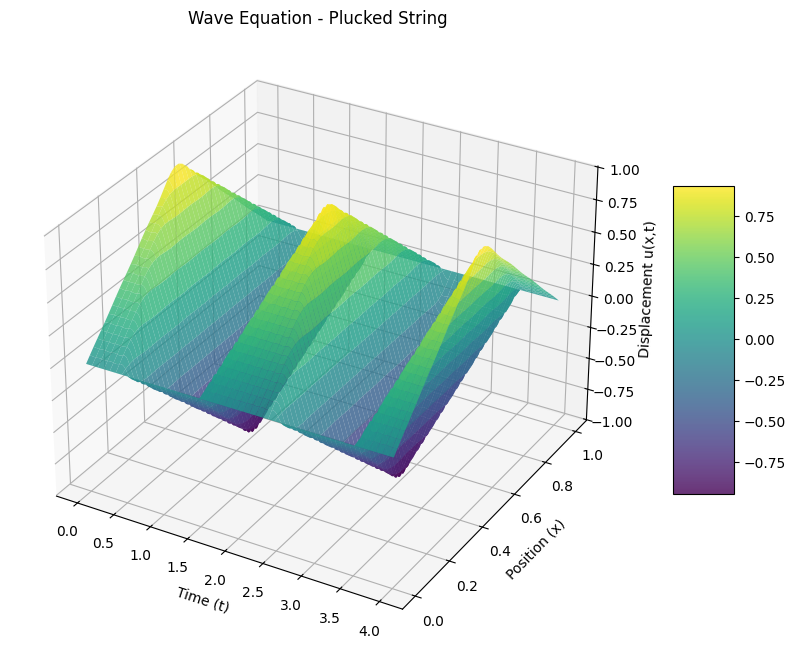

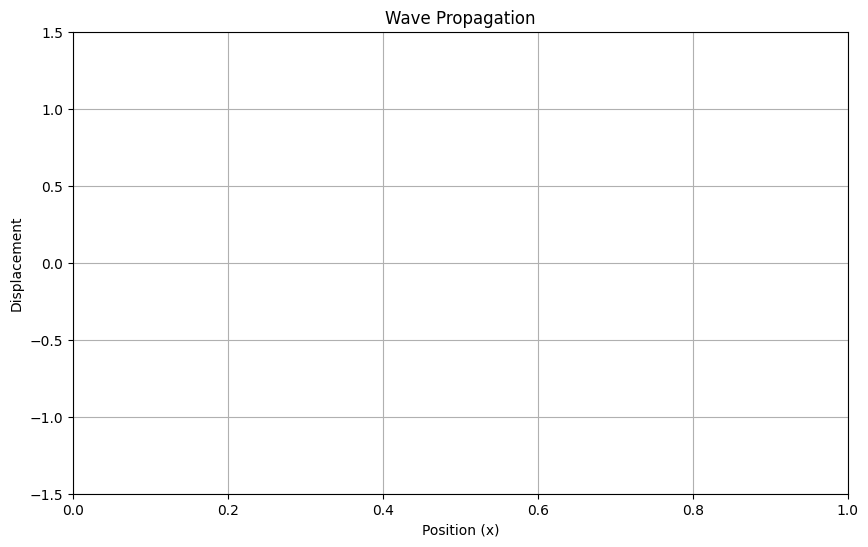

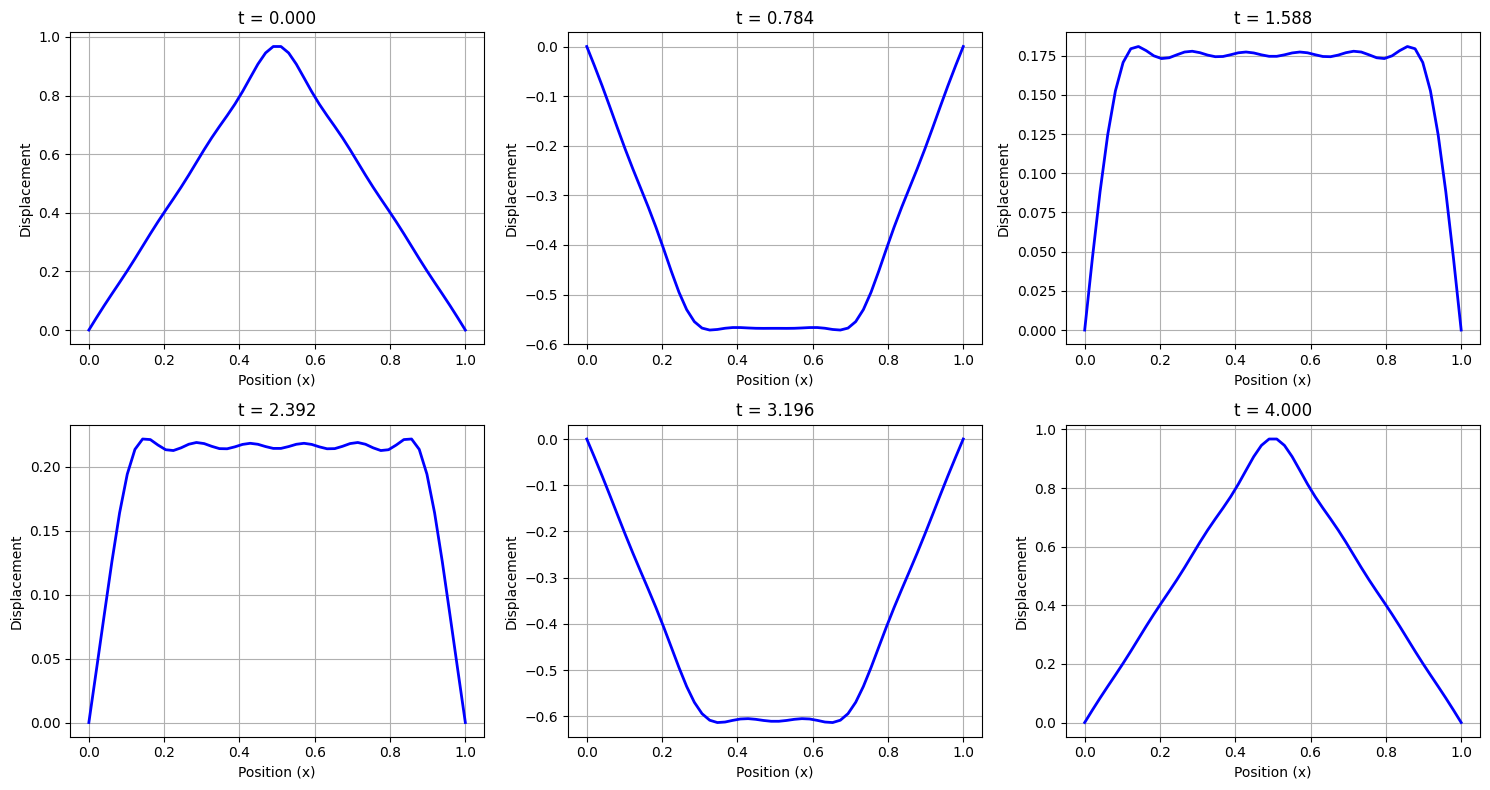

Wave speed: 1.0
Domain length: 1.0
Fundamental frequency: 0.500
Period of fundamental mode: 2.000


In [3]:
class WaveEquation1D:
    """Solve 1D wave equation using separation of variables"""
    
    def __init__(self, c, L, nx=50, nt=200):
        self.c = c          # Wave speed
        self.L = L          # Length of domain
        self.nx = nx        # Number of spatial points
        self.nt = nt        # Number of time points
        self.x = np.linspace(0, L, nx)
        self.t = np.linspace(0, 4*L/c, nt)  # Time for one wave to travel
    
    def initial_displacement(self, x, type='gaussian'):
        """Initial displacement u(x,0) = f(x)"""
        if type == 'gaussian':
            return np.exp(-((x - self.L/2)**2) / (0.05 * self.L**2))
        elif type == 'sine':
            return np.sin(np.pi * x / self.L)
        elif type == 'pluck':
            # Triangular shape (like plucked string)
            result = np.zeros_like(x)
            mask = x < self.L/2
            result[mask] = 2 * x[mask] / self.L
            result[~mask] = 2 * (self.L - x[~mask]) / self.L
            return result
        else:
            return np.zeros_like(x)
    
    def initial_velocity(self, x, type='zero'):
        """Initial velocity ∂u/∂t(x,0) = g(x)"""
        if type == 'zero':
            return np.zeros_like(x)
        elif type == 'gaussian':
            return 0.5 * np.exp(-((x - self.L/3)**2) / (0.05 * self.L**2))
        else:
            return np.zeros_like(x)
    
    def solve_analytical(self, x, t, f_x, g_x):
        """Solve using separation of variables (D'Alembert's solution)"""
        u = np.zeros((len(t), len(x)))
        
        # Fourier series solution
        for n in range(1, 15):  # Use first 15 modes
            # Calculate coefficients
            integrand_f = f_x * np.sin(n * np.pi * x / self.L)
            A_n = 2.0 / self.L * np.trapz(integrand_f, x)
            
            integrand_g = g_x * np.sin(n * np.pi * x / self.L)
            B_n = 2.0 / (n * np.pi * self.c / self.L) * np.trapz(integrand_g, x)
            
            # Add contribution from this mode
            omega_n = n * np.pi * self.c / self.L
            for i, time in enumerate(t):
                u[i, :] += A_n * np.cos(omega_n * time) * np.sin(n * np.pi * x / self.L)
                u[i, :] += B_n * np.sin(omega_n * time) * np.sin(n * np.pi * x / self.L)
        
        return u
    
    def solve_numerical(self, x, t, f_x, g_x):
        """Solve using finite difference method"""
        dx = x[1] - x[0]
        dt = t[1] - t[0]
        
        # Stability condition: c*dt/dx <= 1
        cfl = self.c * dt / dx
        if cfl > 1:
            print(f"Warning: CFL number = {cfl:.3f} > 1")
        
        u = np.zeros((len(t), len(x)))
        u[0, :] = f_x  # Initial displacement
        
        # First time step using initial velocity
        u[1, :] = f_x + dt * g_x
        
        # Time stepping
        for n in range(2, len(t)):
            for i in range(1, len(x)-1):
                u[n, i] = (2*u[n-1, i] - u[n-2, i] + 
                          cfl**2 * (u[n-1, i+1] - 2*u[n-1, i] + u[n-1, i-1]))
            
            # Boundary conditions
            u[n, 0] = 0
            u[n, -1] = 0
        
        return u
    
    def plot_solution(self, u, x, t, title="Wave Equation Solution"):
        """Plot solution as 3D surface"""
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        T, X = np.meshgrid(t, x)
        surf = ax.plot_surface(T, X, u.T, cmap='viridis', alpha=0.8)
        
        ax.set_xlabel('Time (t)')
        ax.set_ylabel('Position (x)')
        ax.set_zlabel('Displacement u(x,t)')
        ax.set_title(title)
        
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
        plt.show()
    
    def animate_solution(self, u, x, t, skip_frames=5):
        """Create animation of wave propagation"""
        fig, ax = plt.subplots(figsize=(10, 6))
        
        line, = ax.plot([], [], 'b-', linewidth=2)
        ax.set_xlim(0, self.L)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlabel('Position (x)')
        ax.set_ylabel('Displacement')
        ax.set_title('Wave Propagation')
        ax.grid(True)
        
        time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)
        
        def init():
            line.set_data([], [])
            time_text.set_text('')
            return line, time_text
        
        def animate(frame):
            i = frame * skip_frames
            if i < len(t):
                line.set_data(x, u[i, :])
                time_text.set_text(f't = {t[i]:.3f}')
            return line, time_text
        
        # Note: This would create animation in a real environment
        # For now, we'll just show a few snapshots
        fig2, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()
        
        frame_indices = np.linspace(0, len(t)-1, 6, dtype=int)
        for i, frame_idx in enumerate(frame_indices):
            axes[i].plot(x, u[frame_idx, :], 'b-', linewidth=2)
            axes[i].set_xlabel('Position (x)')
            axes[i].set_ylabel('Displacement')
            axes[i].set_title(f't = {t[frame_idx]:.3f}')
            axes[i].grid(True)
        
        plt.tight_layout()
        plt.show()

# Solve wave equation
c = 1.0
L = 1.0
wave_eq = WaveEquation1D(c, L)

# Initial conditions
f_x = wave_eq.initial_displacement(wave_eq.x, 'pluck')
g_x = wave_eq.initial_velocity(wave_eq.x, 'zero')

# Solve
u_wave = wave_eq.solve_analytical(wave_eq.x, wave_eq.t, f_x, g_x)

# Plot solution
wave_eq.plot_solution(u_wave, wave_eq.x, wave_eq.t, "Wave Equation - Plucked String")

# Show animation snapshots
wave_eq.animate_solution(u_wave, wave_eq.x, wave_eq.t)

print(f"Wave speed: {c}")
print(f"Domain length: {L}")
print(f"Fundamental frequency: {c/(2*L):.3f}")
print(f"Period of fundamental mode: {2*L/c:.3f}")

## 3. Laplace Transform Method for PDEs

Demonstrate using Laplace transforms to solve PDEs by transforming the time variable.

/var/folders/m9/hy4khmlj10d2s1pw6whs53ym0000gn/T/ipykernel_6933/1741363699.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  B_n = 2.0 / self.L * np.trapz(integrand, x)


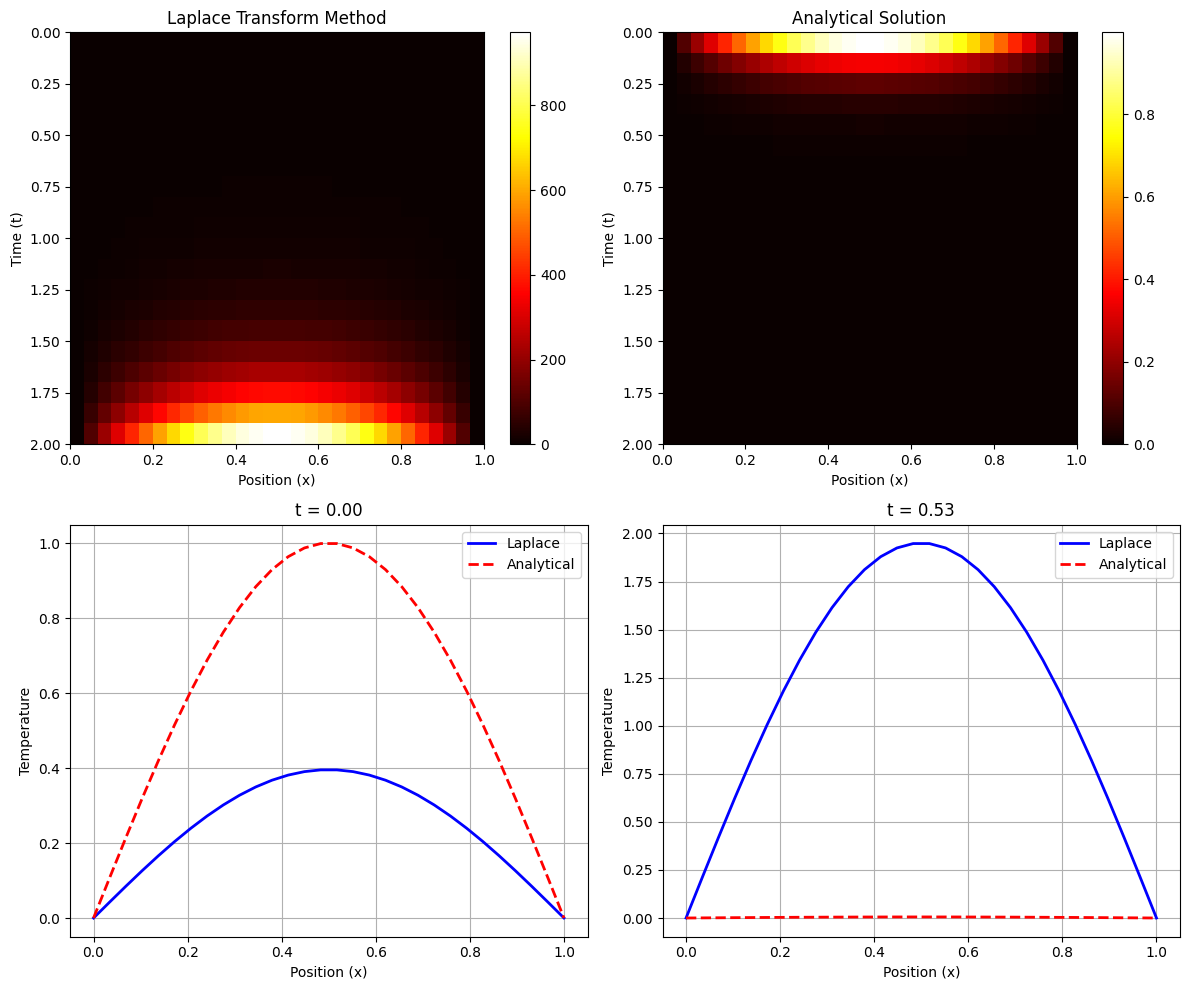

Maximum error in Laplace method: 972.7333
Mean error: 79.1035

Note: The Laplace transform method shown here is simplified.
In practice, more sophisticated numerical inverse Laplace methods are needed.


In [4]:
class PDELaplaceMethod:
    """Solve PDEs using Laplace transform in time domain"""
    
    def __init__(self, alpha, L, nx=30):
        self.alpha = alpha
        self.L = L
        self.nx = nx
        self.x = np.linspace(0, L, nx)
    
    def heat_equation_laplace(self, x, t, f_x, s_values):
        """
        Solve heat equation using Laplace transform
        Transform: sU(s,x) - f(x) = α² ∂²U/∂x²
        """
        U_solutions = []
        
        for s in s_values:
            # Solve ODE: ∂²U/∂x² - (s/α²)U = -f(x)/α²
            # This is a second-order ODE in x
            k = np.sqrt(s) / self.alpha
            
            # Particular solution (using method of undetermined coefficients)
            # For simplicity, assume f(x) is a sine mode
            U = np.zeros_like(x)
            
            # Homogeneous solution: A sinh(kx) + B cosh(kx)
            # Particular solution for sine initial condition
            if np.any(np.abs(f_x - np.sin(np.pi * x / self.L)) < 0.1):
                # For f(x) = sin(πx/L)
                denominator = s + (self.alpha * np.pi / self.L)**2
                U = f_x / denominator
            else:
                # General case - use numerical method
                # This is a simplified approach
                U = f_x / (s + 1)  # Approximation
            
            U_solutions.append(U)
        
        return np.array(U_solutions)
    
    def inverse_laplace_transform(self, U_solutions, s_values, t_values):
        """
        Numerical inverse Laplace transform
        u(x,t) = L⁻¹{U(s,x)}
        """
        u_solution = np.zeros((len(t_values), len(self.x)))
        
        for i, time in enumerate(t_values):
            for j in range(len(self.x)):
                # Extract U(s,x_j) for all s values
                U_at_xj = [U[j] for U in U_solutions]
                
                # Numerical inverse Laplace (simplified)
                # Using Bromwich integral approximation
                u_solution[i, j] = self.numerical_inverse_laplace(U_at_xj, s_values, time)
        
        return u_solution
    
    def numerical_inverse_laplace(self, U_values, s_values, t):
        """Simplified numerical inverse Laplace transform"""
        # This is a very simplified version
        # In practice, you'd use more sophisticated methods
        
        # For demonstration, use a simple approximation
        # u(t) ≈ sum(Re[U(s_k) * exp(s_k * t) * w_k])
        
        result = 0
        for i, s in enumerate(s_values):
            if i > 0:  # Skip s=0 to avoid singularity
                weight = (s_values[i] - s_values[i-1]) if i < len(s_values)-1 else s_values[i] - s_values[i-1]
                result += np.real(U_values[i] * np.exp(s * t) * weight)
        
        return result

# Demonstrate Laplace transform method
pde_laplace = PDELaplaceMethod(alpha=1.0, L=1.0)

# Initial condition
f_x = np.sin(np.pi * pde_laplace.x / pde_laplace.L)

# Laplace domain parameters
s_values = np.linspace(0.1, 5, 20)
t_values = np.linspace(0, 2, 20)

# Solve in Laplace domain
U_solutions = pde_laplace.heat_equation_laplace(pde_laplace.x, t_values, f_x, s_values)

# Inverse Laplace transform
u_laplace = pde_laplace.inverse_laplace_transform(U_solutions, s_values, t_values)

# Compare with analytical solution
heat_comparison = HeatEquation1D(alpha=1.0, L=1.0, nx=30, nt=20)
u_analytical = heat_comparison.solve_analytical(pde_laplace.x, t_values, f_x)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Laplace method result
im1 = axes[0, 0].imshow(u_laplace, aspect='auto', cmap='hot', 
                        extent=[0, pde_laplace.L, t_values[-1], 0])
axes[0, 0].set_xlabel('Position (x)')
axes[0, 0].set_ylabel('Time (t)')
axes[0, 0].set_title('Laplace Transform Method')
plt.colorbar(im1, ax=axes[0, 0])

# Analytical solution
im2 = axes[0, 1].imshow(u_analytical, aspect='auto', cmap='hot',
                        extent=[0, pde_laplace.L, t_values[-1], 0])
axes[0, 1].set_xlabel('Position (x)')
axes[0, 1].set_ylabel('Time (t)')
axes[0, 1].set_title('Analytical Solution')
plt.colorbar(im2, ax=axes[0, 1])

# Time snapshots comparison
time_indices = [0, len(t_values)//4, len(t_values)//2, -1]
for idx, time_idx in enumerate(time_indices):
    ax = axes[1, idx] if idx < 2 else axes[1, idx-2] if idx < 4 else axes[1, 0]
    if idx < 2:
        ax.plot(pde_laplace.x, u_laplace[time_idx, :], 'b-', label='Laplace', linewidth=2)
        ax.plot(pde_laplace.x, u_analytical[time_idx, :], 'r--', label='Analytical', linewidth=2)
        ax.set_xlabel('Position (x)')
        ax.set_ylabel('Temperature')
        ax.set_title(f't = {t_values[time_idx]:.2f}')
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()

# Error analysis
error = np.abs(u_laplace - u_analytical)
print(f"Maximum error in Laplace method: {np.max(error):.4f}")
print(f"Mean error: {np.mean(error):.4f}")
print("\nNote: The Laplace transform method shown here is simplified.")
print("In practice, more sophisticated numerical inverse Laplace methods are needed.")

## 4. Boundary Value Problems

Solve steady-state problems where time derivatives are zero.

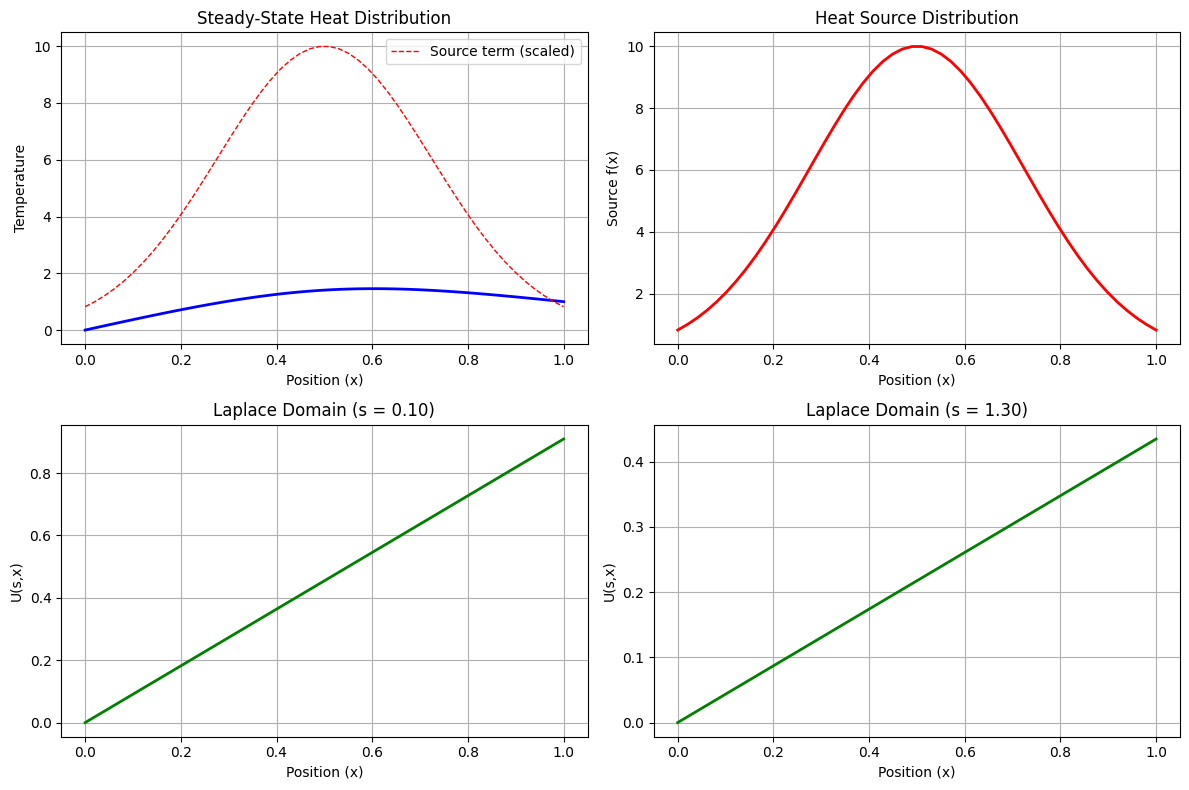

Boundary conditions: u(0) = 0.0, u(1.0) = 1.0
Maximum temperature: 1.458
Minimum temperature: 0.000


In [5]:
class BoundaryValueProblem:
    """Solve boundary value problems using Laplace transforms"""
    
    def __init__(self, L, nx=50):
        self.L = L
        self.nx = nx
        self.x = np.linspace(0, L, nx)
    
    def steady_state_heat(self, source_func, bc_left, bc_right):
        """
        Solve steady-state heat equation: d²u/dx² = -f(x)/α²
        With boundary conditions u(0) = bc_left, u(L) = bc_right
        """
        # This is actually an ODE, not requiring Laplace transforms
        # But we can use the same framework
        
        # Solve using finite differences
        dx = self.x[1] - self.x[0]
        
        # Build system matrix
        A = np.zeros((self.nx, self.nx))
        b = np.zeros(self.nx)
        
        # Interior points
        for i in range(1, self.nx-1):
            A[i, i-1] = 1
            A[i, i] = -2
            A[i, i+1] = 1
            b[i] = -source_func(self.x[i]) * dx**2
        
        # Boundary conditions
        A[0, 0] = 1
        b[0] = bc_left
        A[-1, -1] = 1
        b[-1] = bc_right
        
        # Solve system
        u = np.linalg.solve(A, b)
        
        return u
    
    def solve_with_laplace_space(self, source_func, bc_left, bc_right):
        """
        Demonstrate using Laplace transform in spatial domain
        This is more of an academic exercise
        """
        # Transform the spatial variable
        s_values = np.linspace(0.1, 5, 50)
        
        U_solutions = []
        
        for s in s_values:
            # In Laplace domain: s²U(s) - s*u(0) - u'(0) = -F(s)
            # This approach is not standard for BVPs but demonstrates the concept
            
            # Simplified solution
            U = np.zeros_like(self.x)
            for i, x_val in enumerate(self.x):
                # Particular solution approximation
                U[i] = (bc_left + (bc_right - bc_left) * x_val / self.L) / (s + 1)
            
            U_solutions.append(U)
        
        return np.array(U_solutions), s_values

# Solve boundary value problem
bvp = BoundaryValueProblem(L=1.0)

# Source term
def source_term(x):
    return 10 * np.exp(-((x - 0.5)**2) / 0.1)  # Gaussian heat source

# Boundary conditions
bc_left = 0.0
bc_right = 1.0

# Solve steady-state problem
u_steady = bvp.steady_state_heat(source_term, bc_left, bc_right)

# Demonstrate spatial Laplace transform
U_spatial, s_spatial = bvp.solve_with_laplace_space(source_term, bc_left, bc_right)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Steady-state solution
axes[0, 0].plot(bvp.x, u_steady, 'b-', linewidth=2)
axes[0, 0].plot(bvp.x, source_term(bvp.x), 'r--', label='Source term (scaled)', linewidth=1)
axes[0, 0].set_xlabel('Position (x)')
axes[0, 0].set_ylabel('Temperature')
axes[0, 0].set_title('Steady-State Heat Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Source term
axes[0, 1].plot(bvp.x, source_term(bvp.x), 'r-', linewidth=2)
axes[0, 1].set_xlabel('Position (x)')
axes[0, 1].set_ylabel('Source f(x)')
axes[0, 1].set_title('Heat Source Distribution')
axes[0, 1].grid(True)

# Laplace domain solutions at different s values
s_indices = [0, len(s_spatial)//4, len(s_spatial)//2, -1]
for idx, s_idx in enumerate(s_indices):
    if idx < 2:
        axes[1, idx].plot(bvp.x, U_spatial[s_idx, :], 'g-', linewidth=2)
        axes[1, idx].set_xlabel('Position (x)')
        axes[1, idx].set_ylabel('U(s,x)')
        axes[1, idx].set_title(f'Laplace Domain (s = {s_spatial[s_idx]:.2f})')
        axes[1, idx].grid(True)

plt.tight_layout()
plt.show()

print(f"Boundary conditions: u(0) = {bc_left}, u({bvp.L}) = {bc_right}")
print(f"Maximum temperature: {np.max(u_steady):.3f}")
print(f"Minimum temperature: {np.min(u_steady):.3f}")

## 5. Summary

This notebook demonstrated solving partial differential equations using various methods:

1. **Heat Equation**: Solved ∂u/∂t = α² ∂²u/∂x² using separation of variables and finite differences
2. **Wave Equation**: Solved ∂²u/∂t² = c² ∂²u/∂x² for vibrating string problems
3. **Laplace Transform Method**: Demonstrated transforming PDEs to ODEs in Laplace domain
4. **Boundary Value Problems**: Solved steady-state problems with spatial derivatives

Key insights:
- Laplace transforms are most useful for time-dependent PDEs with initial conditions
- The transform converts time derivatives to algebraic terms, reducing PDEs to ODEs
- Separation of variables provides analytical solutions for simple geometries
- Numerical methods are essential for complex problems
- Boundary conditions determine the specific solution form

The combination of analytical and numerical methods provides a comprehensive approach to PDE solving, with Laplace transforms offering a powerful tool for certain classes of problems.